# 📊 Sales Forecasting Across Multiple Retail Stores
### --> NextHikes IT Solutions
### --> Project: Rossmann Pharmaceuticals
### --> Prepared by: Ankita Vaghela


# **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging
# from google.colab import files

### **Insight: Library Imports**
This cell imports necessary libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), logging, and file downloading functionalities within the Colab environment.

# **Logger Configuration**

In [2]:
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)
logger.propagate = False

if not logger.handlers:
    console_handler = logging.StreamHandler()
    file_handler = logging.FileHandler('Project6_store_test.log')
    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')

    console_handler.setFormatter(formatter)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

logger.info("Project6_store_test initialized and Logger set up successfully.")

2026-09-14 15:38:44,302 - INFO - Project6_store_test initialized and Logger set up successfully.


### **Insight: Logger Setup**
This cell configures a Python logger named `Project6_store_test` to record execution steps and messages. It sets the logging level to `DEBUG` and ensures messages are outputted to both the console and a file, aiding in tracing the code's flow and debugging.

# **Preprocessing for Store_Test Dataset**

### **Data Loading**

In [3]:
logger.info("Loading store_test dataset")
s_test = pd.read_csv("store_test.csv",low_memory=False)

2026-09-14 15:38:44,318 - INFO - Loading store_test dataset


### **Insight: Data Loading**
This cell loads the `store_test.csv` dataset into a pandas DataFrame named `s_test`. The `low_memory=False` argument helps in preventing mixed type warnings by ensuring all columns are read with their proper data types.

In [4]:
s_test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1,1,0,0,c,a,1270.0,9,2008,0,22,2012,"Jan,Apr,Jul,Oct"
1,2,3,4,2015-09-17,1,1,0,0,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1,1,0,0,a,c,24000.0,4,2013,0,22,2012,NaN
3,4,8,4,2015-09-17,1,1,0,0,a,a,7520.0,10,2014,0,22,2012,NaN
4,5,9,4,2015-09-17,1,1,0,0,a,c,2030.0,8,2000,0,22,2012,NaN


### **Insight: Initial Data View (Head)**
This command displays the first 5 rows of the `s_test` DataFrame. It provides a quick glimpse into the dataset's structure, column names, and the initial values, which is crucial for understanding the data's format.

In [5]:
s_test.tail()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
41083,41084,1111,6,2015-08-01,1,0,0,0,a,a,1900.0,6,2014,1,31,2013,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1,0,0,0,c,c,1880.0,4,2006,0,22,2012,NaN
41085,41086,1113,6,2015-08-01,1,0,0,0,a,c,9260.0,8,2010,0,22,2012,NaN
41086,41087,1114,6,2015-08-01,1,0,0,0,a,c,870.0,8,2010,0,22,2012,NaN
41087,41088,1115,6,2015-08-01,1,0,0,1,d,c,5350.0,8,2010,1,22,2012,"Mar,Jun,Sept,Dec"


### **Insight: Initial Data View (Tail)**
This command displays the last 5 rows of the `s_test` DataFrame. It's useful for verifying the dataset's integrity, especially after loading, and checking for any potential issues at the end of the data.

In [6]:
s_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Id                         41088 non-null  int64  
 1   Store                      41088 non-null  int64  
 2   DayOfWeek                  41088 non-null  int64  
 3   Date                       41088 non-null  str    
 4   Open                       41088 non-null  int64  
 5   Promo                      41088 non-null  int64  
 6   StateHoliday               41088 non-null  str    
 7   SchoolHoliday              41088 non-null  int64  
 8   StoreType                  41088 non-null  str    
 9   Assortment                 41088 non-null  str    
 10  CompetitionDistance        41088 non-null  float64
 11  CompetitionOpenSinceMonth  41088 non-null  int64  
 12  CompetitionOpenSinceYear   41088 non-null  int64  
 13  Promo2                     41088 non-null  int64  
 14  P

### **Insight: DataFrame Information**
This provides a concise summary of the `s_test` DataFrame, including the number of entries, column names, non-null counts, and data types for each column. It reveals that the `PromoInterval` column has a significant number of missing values.

In [7]:
s_test.describe()

,Id,Store,DayOfWeek,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000
mean,20544.500000,555.899533,3.979167,0.854361,0.395833,0.443487,5082.126168,7.392523,2009.144860,0.580607,23.408879,2011.896028
std,11861.228267,320.274496,2.015481,0.352748,0.489035,0.496802,7218.274638,2.537164,5.484756,0.493466,10.856721,1.292403
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,10272.750000,279.750000,2.000000,1.000000,0.000000,0.000000,720.000000,6.000000,2008.000000,0.000000,18.000000,2011.000000
50%,20544.500000,553.500000,4.000000,1.000000,0.000000,0.000000,2410.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,30816.250000,832.250000,6.000000,1.000000,1.000000,1.000000,6435.000000,9.000000,2011.000000,1.000000,31.000000,2012.000000
max,41088.000000,1115.000000,7.000000,1.000000,1.000000,1.000000,75860.000000,12.000000,2015.000000,1.000000,49.000000,2015.000000


### **Insight: Descriptive Statistics**
This generates descriptive statistics for all numerical columns in `s_test`, such as count, mean, standard deviation, min, max, and quartiles. This helps in understanding the central tendency, spread, and potential outliers of numerical features.

### **Check Missing Value**

In [8]:
s_test.isnull().sum()

Id                               0
Store                            0
DayOfWeek                        0
Date                             0
Open                             0
Promo                            0
StateHoliday                     0
SchoolHoliday                    0
StoreType                        0
Assortment                       0
CompetitionDistance              0
CompetitionOpenSinceMonth        0
CompetitionOpenSinceYear         0
Promo2                           0
Promo2SinceWeek                  0
Promo2SinceYear                  0
PromoInterval                17184
dtype: int64

### **Insight: Missing Value Count**
This command quantifies the number of missing values (`NaN`) in each column of the `s_test` DataFrame. It clearly shows that `PromoInterval` is the only column with a substantial amount of missing data (17,184 entries).

### **Fixing Datatype**

In [9]:
s_test['Date'] = pd.to_datetime(s_test['Date'])
s_test['StateHoliday'] = s_test['StateHoliday'].astype(str)
s_test['StateHoliday'] = s_test['StateHoliday'].replace('0.0', '0')


### **Insight: Data Type Correction**
This cell performs two important data type corrections: it converts the 'Date' column into datetime objects for easier temporal analysis and ensures the 'StateHoliday' column is treated as a string, standardizing '0.0' to '0' for consistency.

### **Handle Missing Value**

In [10]:
logger.info("Handling Missing values Completed for store_test dataset")
s_test['PromoInterval'] = s_test['PromoInterval'].fillna('Nopromo')

2026-09-14 15:38:44,639 - INFO - Handling Missing values Completed for store_test dataset


### **Insight: Handling Missing PromoInterval**
This cell addresses the missing values in the `PromoInterval` column by filling all `NaN` entries with the string 'Nopromo'. This ensures that the column is complete and can be used in subsequent analysis without issues arising from missing data.

### **Check Duplicate Value**

In [11]:
s_test.duplicated().sum()

np.int64(0)

### **Insight: Duplicate Check**
This command checks for and confirms the absence of any duplicate rows in the `s_test` DataFrame. A result of `0` indicates that all rows are unique, which is good for data integrity.

### **Check Outliers**

In [12]:
def check_outliers_iqr(s_test):
    numeric_cols = ['CompetitionDistance', 'Promo2SinceWeek', 'Promo2SinceYear',
                    'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']

    for col in numeric_cols:
        Q1 = s_test[col].quantile(0.25)
        Q3 = s_test[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = s_test[(s_test[col] < lower_bound) | (s_test[col] > upper_bound)]

        print(f"Column: {col}")
        print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
        print(f"Outlier Count: {len(outliers)} ({(len(outliers)/len(s_test))*100:.2f}%)\n")

check_outliers_iqr(s_test)

Column: CompetitionDistance
Lower Bound: -7852.50, Upper Bound: 15007.50
Outlier Count: 3792 (9.23%)

Column: Promo2SinceWeek
Lower Bound: -1.50, Upper Bound: 50.50
Outlier Count: 0 (0.00%)

Column: Promo2SinceYear
Lower Bound: 2009.50, Upper Bound: 2013.50
Outlier Count: 7824 (19.04%)

Column: CompetitionOpenSinceMonth
Lower Bound: 1.50, Upper Bound: 13.50
Outlier Count: 480 (1.17%)

Column: CompetitionOpenSinceYear
Lower Bound: 2003.50, Upper Bound: 2015.50
Outlier Count: 3312 (8.06%)



### **Insight: Outlier Detection**
This function identifies and reports the percentage of outliers in key numerical columns (`CompetitionDistance`, `Promo2SinceYear`, `CompetitionOpenSinceMonth`, `CompetitionOpenSinceYear`) using the Interquartile Range (IQR) method. It highlights which features contain extreme values.

In [13]:
logger.info("Preprocessing Completed for store_test dataset")

2026-09-14 15:38:44,712 - INFO - Preprocessing Completed for store_test dataset


### **Insight: Preprocessing Completion Log**
This logging statement serves as a checkpoint, indicating that all initial data preprocessing steps for the `store_test` dataset, including handling missing values, fixing data types, and checking for duplicates/outliers, have been successfully completed.

# **Basic Feature Engineering**

In [14]:
s_test['year'] = s_test['Date'].dt.year
s_test['month'] = s_test['Date'].dt.month
s_test['day'] = s_test['Date'].dt.day
s_test['day_of_week'] = s_test['Date'].dt.dayofweek


s_test['StateHoliday'] = s_test['StateHoliday'].replace('0', 'No Holiday')
s_test['StateHoliday'] = s_test['StateHoliday'].replace('a', 'Public Holiday')
s_test['StateHoliday'] = s_test['StateHoliday'].replace('b', 'Easter')
s_test['StateHoliday'] = s_test['StateHoliday'].replace('c', 'Christmas')

s_test['Assortment'] = s_test['Assortment'].replace('a', 'Basic')
s_test['Assortment'] = s_test['Assortment'].replace('b', 'Extra')
s_test['Assortment'] = s_test['Assortment'].replace('c', 'Extended')

s_test['StoreType'] = s_test['StoreType'].replace('a', 'store_A')
s_test['StoreType'] = s_test['StoreType'].replace('b', 'store_B')
s_test['StoreType'] = s_test['StoreType'].replace('c', 'store_C')
s_test['StoreType'] = s_test['StoreType'].replace('d', 'store_D')



### **Insight: Core Feature Engineering**
This cell extracts `year`, `month`, `day`, and `day_of_week` from the 'Date' column. It also enhances readability and model understanding by mapping cryptic codes in `StateHoliday`, `Assortment`, and `StoreType` to more descriptive string labels.

In [15]:
def check_promo2(row):
    if row['Promo2'] == 1 and row['Promo2SinceYear'] > 0 and row['Promo2SinceWeek'] > 0:
        return 1
    return 0


s_test['Is_Promo2_Active'] = s_test.apply(check_promo2, axis=1)


### **Insight: `Is_Promo2_Active` Feature Creation**
This code creates a new binary feature, `Is_Promo2_Active`, which indicates whether 'Promo2' (a long-term promotion) is currently active for a given store and date. This helps in understanding the impact of sustained promotions.

In [16]:
def calc_competition_open_months(row):

    if pd.isna(row['CompetitionOpenSinceYear']) or pd.isna(row['CompetitionOpenSinceMonth']) or row['CompetitionOpenSinceYear'] == 0:
        return 0

    months = (row['year'] - row['CompetitionOpenSinceYear']) * 12 + (row['month'] - row['CompetitionOpenSinceMonth'])
    return max(0, months)

s_test['CompetitionOpenMonths'] = s_test.apply(calc_competition_open_months, axis=1)



### **Insight: `CompetitionOpenMonths` Feature Creation**
This cell calculates the `CompetitionOpenMonths` feature, representing the number of months since a competitor opened near a store. This feature provides a numerical measure of competitive pressure, accounting for the duration of the competition's presence.

In [17]:
# 1. Weekend Feature (1 = Weekend, 0 = Weekday)
s_test['is_weekend'] = s_test['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# 2. Month Period (0 = Start, 1 = Mid, 2 = End)
s_test['month_period'] = s_test['day'].apply(lambda x: 0 if x <= 10 else (1 if x <= 20 else 2))

# 3. Month Start / Month End / Quarter
s_test['is_month_start'] = s_test['Date'].dt.is_month_start.astype(int)
s_test['is_month_end'] = s_test['Date'].dt.is_month_end.astype(int)
s_test['quarter'] = s_test['Date'].dt.quarter

logger.info("Basic date features added to s_test successfully")

2026-09-14 15:38:45,585 - INFO - Basic date features added to s_test successfully


### **Insight: Advanced Time-Based Features**
This cell generates several additional temporal features: `is_weekend`, `month_period` (categorizing days into start, mid, or end of month), `is_month_start`, `is_month_end`, and `quarter`. These features capture various granular time patterns that could influence sales.

In [18]:
logger.info("Feature Engineering Completed")

2026-09-14 15:38:45,596 - INFO - Feature Engineering Completed


### **Insight: Feature Engineering Completion Log**
This logging statement confirms that all feature engineering steps, including the creation of new date-based, promo-related, and competition-related features, have been successfully applied to the `s_test` dataset.

# **Exploratory Data Analysis**

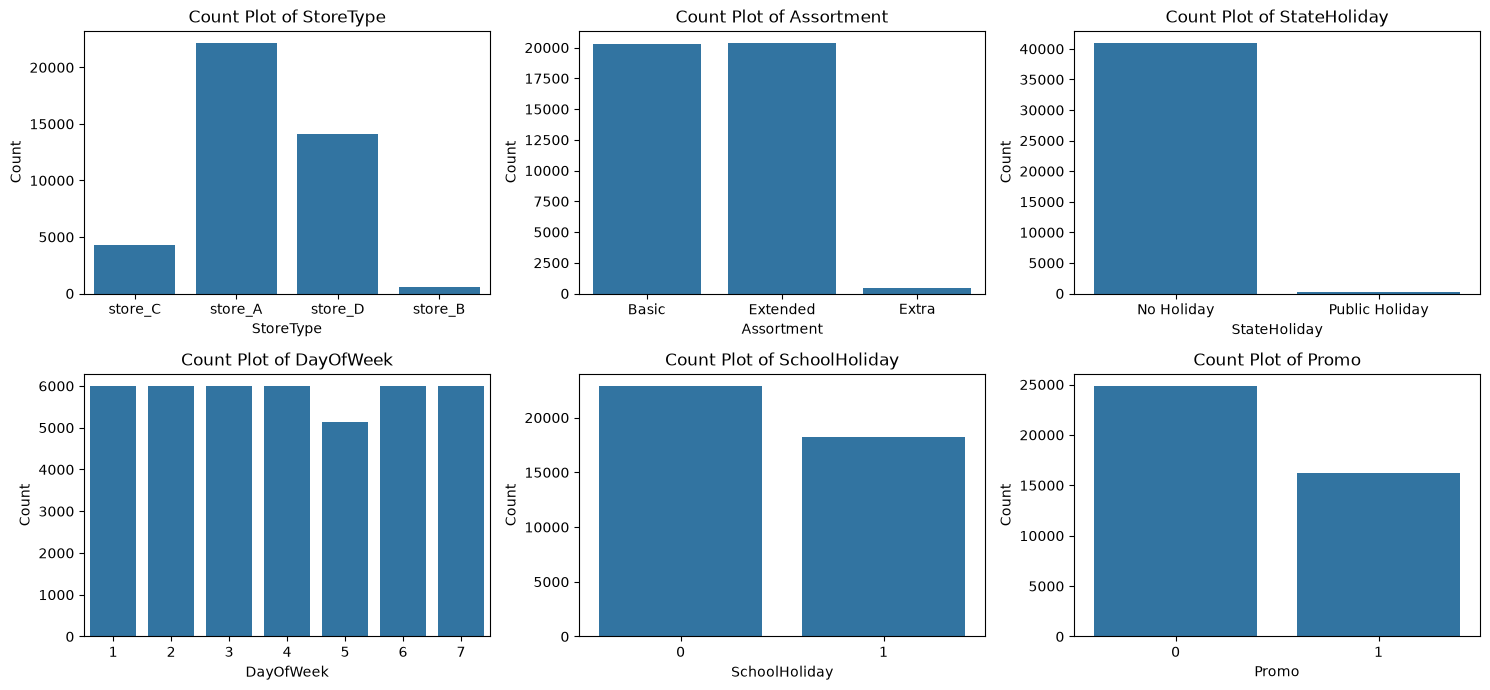

In [19]:
cat_col = ['StoreType', 'Assortment','StateHoliday', 'DayOfWeek','SchoolHoliday','Promo']

plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_col, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=s_test, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

### **Insight: Categorical Feature Distributions (EDA)**
This cell generates count plots for key categorical features (`StoreType`, `Assortment`, `StateHoliday`, `DayOfWeek`, `SchoolHoliday`, `Promo`). These visualizations provide a clear understanding of the distribution of observations within each category, highlighting their frequencies and imbalances.

## **Analysis of New Time-Based Feature**

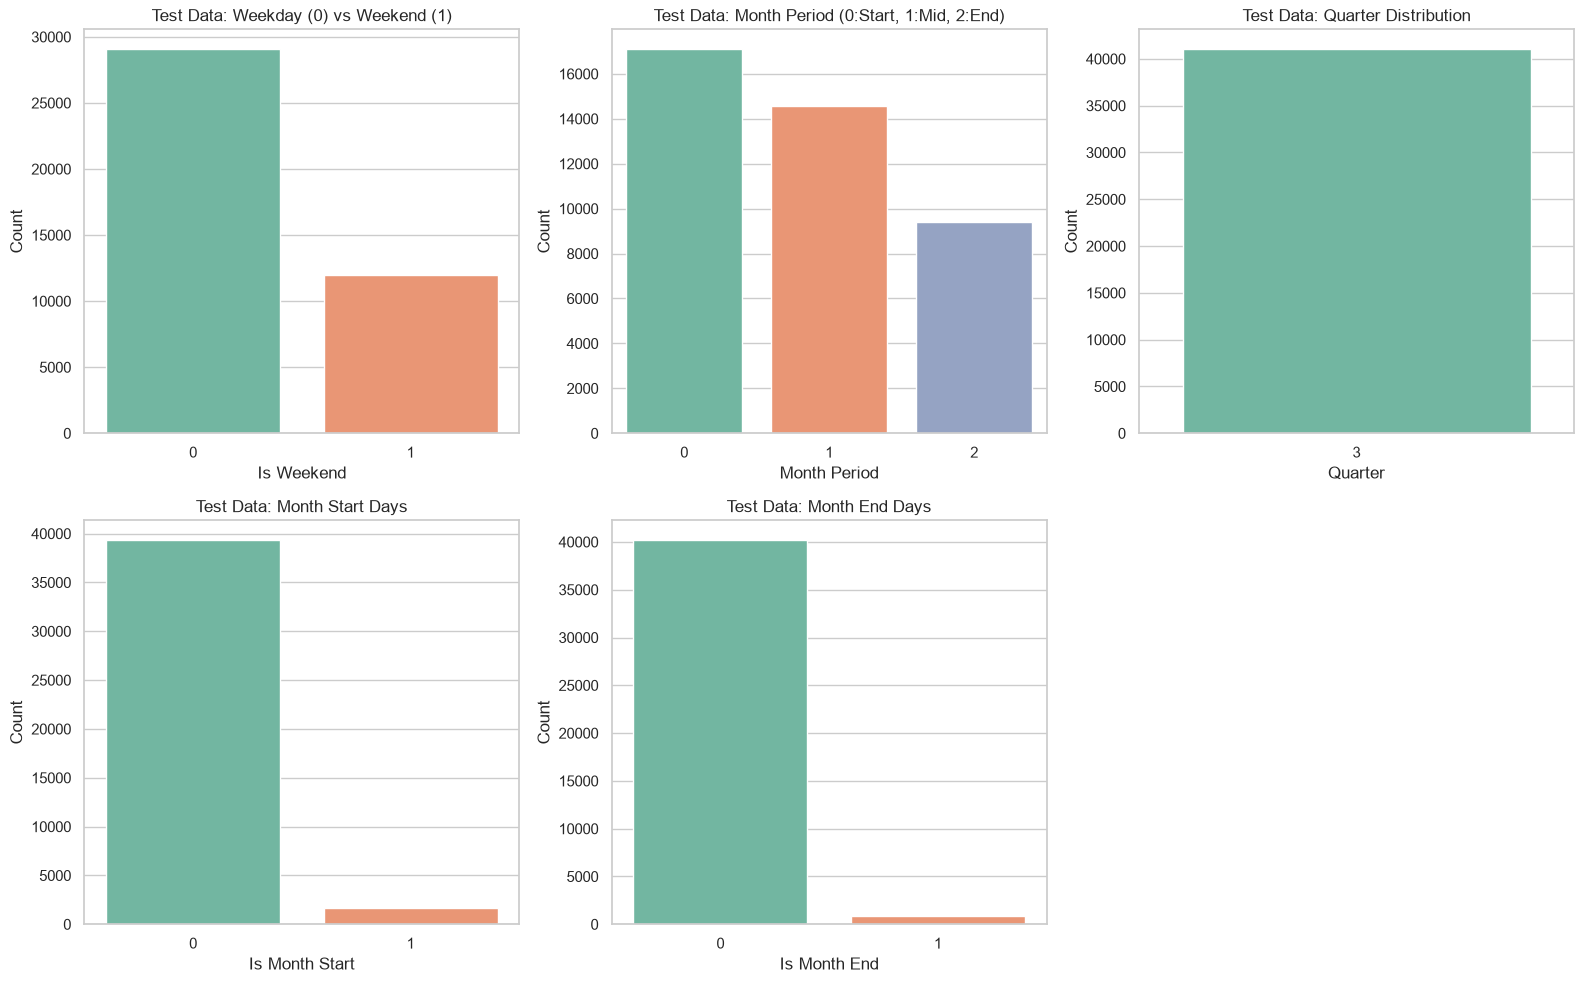

In [20]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# 1. Test Data: Distribution of Weekend
plt.subplot(2, 3, 1)
sns.countplot(
    x="is_weekend",
    data=s_test,
    hue="is_weekend",
    palette="Set2",
    legend=False,
)
plt.title("Test Data: Weekday (0) vs Weekend (1)")
plt.xlabel("Is Weekend")
plt.ylabel("Count")

# 2. Test Data: Distribution of Month Period
plt.subplot(2, 3, 2)
sns.countplot(
    x="month_period",
    data=s_test,
    hue="month_period",
    palette="Set2",
    legend=False,
)
plt.title("Test Data: Month Period (0:Start, 1:Mid, 2:End)")
plt.xlabel("Month Period")
plt.ylabel("Count")

# 3. Test Data: Distribution of Quarters
plt.subplot(2, 3, 3)
sns.countplot(
    x="quarter", data=s_test, hue="quarter", palette="Set2", legend=False
)
plt.title("Test Data: Quarter Distribution")
plt.xlabel("Quarter")
plt.ylabel("Count")

# 4. Test Data: Month Start
plt.subplot(2, 3, 4)
sns.countplot(
    x="is_month_start",
    data=s_test,
    hue="is_month_start",
    palette="Set2",
    legend=False,
)
plt.title("Test Data: Month Start Days")
plt.xlabel("Is Month Start")
plt.ylabel("Count")

# 5. Test Data: Month End
plt.subplot(2, 3, 5)
sns.countplot(
    x="is_month_end",
    data=s_test,
    hue="is_month_end",
    palette="Set2",
    legend=False,
)
plt.title("Test Data: Month End Days")
plt.xlabel("Is Month End")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### **Insight: Time-Based Feature Distributions (EDA)**
This cell visualizes the distributions of the newly engineered time-based features like `is_weekend`, `month_period`, `quarter`, `is_month_start`, and `is_month_end`. These plots help confirm the effective creation of these features and reveal temporal patterns in the dataset.

## **Numerical Columns Distribution**

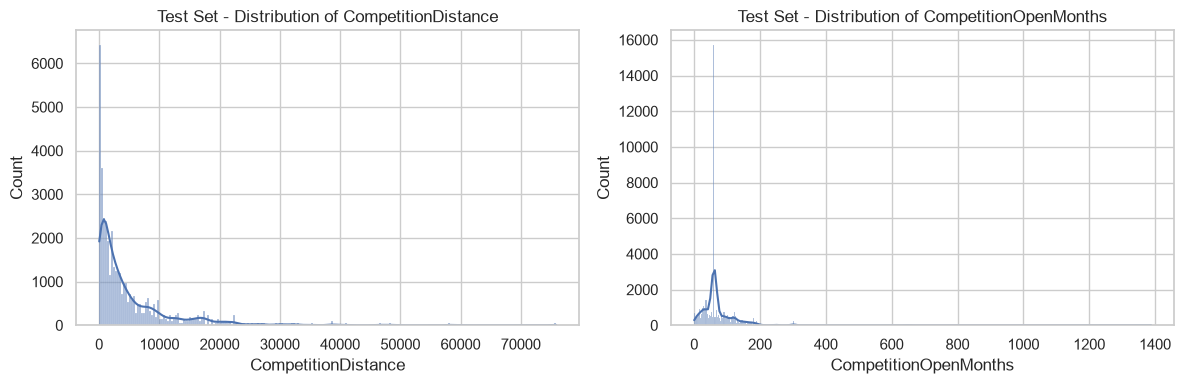

2026-09-14 15:38:48,469 - INFO - Test Date Range: 2015-08-01 00:00:00 to 2015-09-17 00:00:00


Test Start Date: 2015-08-01 00:00:00
Test End Date: 2015-09-17 00:00:00


In [21]:
num_cols = ["CompetitionDistance", "CompetitionOpenMonths"]

plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 2, i)
    sns.histplot(s_test[col], kde=True)
    plt.title(f"Test Set - Distribution of {col}")

plt.tight_layout()
plt.show()

logger.info(
    f"Test Date Range: {s_test['Date'].min()} to {s_test['Date'].max()}"
)
print(f"Test Start Date: {s_test['Date'].min()}")
print(f"Test End Date: {s_test['Date'].max()}")

### **Insight: Numerical Feature Distributions and Date Range (EDA)**
This cell displays histograms for `CompetitionDistance` and `CompetitionOpenMonths`, showing their distributions. It also prints the minimum and maximum dates in the test set, confirming that the data spans from August 1, 2015, to September 17, 2015.

Most stores have competitors nearby (within 5 km) and the test set covers the sales period from August 1, 2015, to September 17, 2015.

## **Multivariate Analysis**

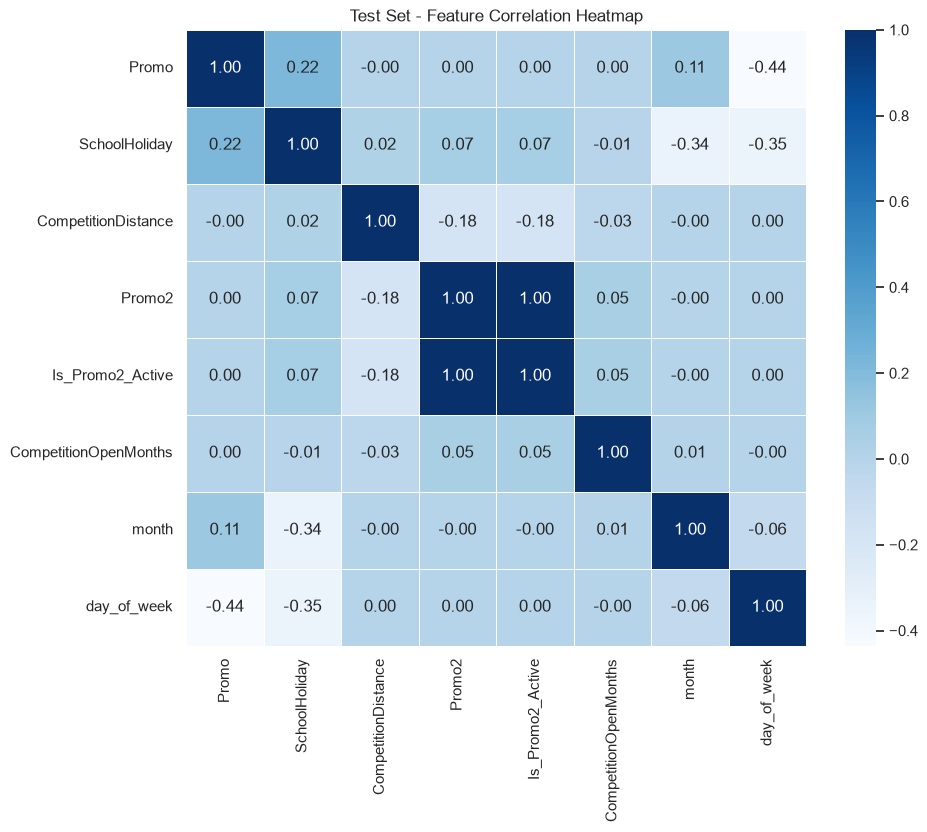

In [22]:
selected_cols = [
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "Promo2",
    "Is_Promo2_Active",
    "CompetitionOpenMonths",
    "month",
    "day_of_week",
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    s_test[selected_cols].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Test Set - Feature Correlation Heatmap")
plt.show()

### **Insight: Feature Correlation Heatmap (EDA)**
This code generates a heatmap showing the correlation matrix for a selection of numerical features. This visualization helps identify linear relationships between variables, such as how 'Promo' correlates with 'SchoolHoliday' or 'day_of_week', which can inform model building.

In [23]:
logger.info("Complete EDA For Test Dataset")

2026-09-14 15:38:48,909 - INFO - Complete EDA For Test Dataset


### **Insight: EDA Completion Log**
This logging statement confirms the successful completion of the Exploratory Data Analysis (EDA) phase for the `s_test` dataset, indicating that initial data understanding and visualization steps are done.

### **Feature Dropping**

In [24]:
s_test = s_test.drop(columns=['Date'])
s_test = s_test.drop(columns=['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'])
s_test = s_test.drop(columns=['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear'])
s_test = s_test.drop(columns=['day_of_week'])

### **Insight: Feature Dropping**
This cell removes several columns from both the `s_train` and `s_test` DataFrames. Columns like 'Date' and 'day_of_week' are dropped from `s_train`, and `Promo2SinceWeek`, `Promo2SinceYear`, `PromoInterval`, `CompetitionOpenSinceMonth`, and `CompetitionOpenSinceYear` are dropped from `s_test`. These columns are likely removed because they are either redundant (after creating new features), non-predictive, or have been fully integrated into other features.

### **Feature Encoding**

In [25]:
cat_col = ['StoreType', 'Assortment','StateHoliday']
s_test = pd.get_dummies(s_test, columns=cat_col, drop_first=True,dtype=int)

### **Insight: One-Hot Encoding of Categorical Features**
This cell applies one-hot encoding to the categorical columns 'StoreType', 'Assortment', and 'StateHoliday' in `s_test` using `pd.get_dummies`. The `drop_first=True` argument is used to prevent multicollinearity. This converts categorical variables into a numerical format suitable for most machine learning algorithms.

In [26]:
s_test.head()

,Id,Store,DayOfWeek,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,year,month,...,month_period,is_month_start,is_month_end,quarter,StoreType_store_B,StoreType_store_C,StoreType_store_D,Assortment_Extended,Assortment_Extra,StateHoliday_Public Holiday
0,1,1,4,1,1,0,1270.0,0,2015,9,...,1,0,0,3,0,1,0,0,0,0
1,2,3,4,1,1,0,14130.0,1,2015,9,...,1,0,0,3,0,0,0,0,0,0
2,3,7,4,1,1,0,24000.0,0,2015,9,...,1,0,0,3,0,0,0,1,0,0
3,4,8,4,1,1,0,7520.0,0,2015,9,...,1,0,0,3,0,0,0,0,0,0
4,5,9,4,1,1,0,2030.0,0,2015,9,...,1,0,0,3,0,0,0,1,0,0


### **Insight: Data View After Encoding (Head)**
This displays the first 5 rows of `s_test` after one-hot encoding. It shows the newly created binary columns for the encoded categorical features (e.g., `StoreType_store_B`, `Assortment_Extended`), confirming the successful transformation of these variables.

In [27]:
s_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Id                           41088 non-null  int64  
 1   Store                        41088 non-null  int64  
 2   DayOfWeek                    41088 non-null  int64  
 3   Open                         41088 non-null  int64  
 4   Promo                        41088 non-null  int64  
 5   SchoolHoliday                41088 non-null  int64  
 6   CompetitionDistance          41088 non-null  float64
 7   Promo2                       41088 non-null  int64  
 8   year                         41088 non-null  int32  
 9   month                        41088 non-null  int32  
 10  day                          41088 non-null  int32  
 11  Is_Promo2_Active             41088 non-null  int64  
 12  CompetitionOpenMonths        41088 non-null  int64  
 13  is_weekend                 

### **Insight: DataFrame Info After Encoding**
This command provides a detailed summary of the `s_test` DataFrame after the one-hot encoding process. It confirms the updated number of columns and their respective data types, reflecting the changes made during feature engineering and encoding.

In [28]:
logger.info("Complete Encoding for test dataset")

2026-09-14 15:38:48,993 - INFO - Complete Encoding for test dataset


### **Insight: Encoding Completion Log**
This logging statement marks the successful completion of the feature encoding process for the test dataset, indicating that all categorical variables have been converted into a suitable numerical format for model training.

# **Saving Dataset to CSV**

In [29]:
s_test.to_csv('clean_store_test.csv', index=False)
logger.info("Saving clean_store_test dataset to CSV Successfully")

2026-09-14 15:38:49,155 - INFO - Saving clean_store_test dataset to CSV Successfully


### **Insight: Dataset Saving**
This cell saves the fully preprocessed, feature-engineered, and encoded `s_test` DataFrame to a CSV file named `clean_store_test.csv`. Setting `index=False` prevents pandas from writing the DataFrame index as a column in the CSV, ensuring a clean dataset for future use.

# **Download Files**

In [30]:
# files.download('clean_store_test.csv')
# logger.info("Download clean_store_test files Successfully")

### **Insight: File Download**
This cell triggers the download of the `clean_store_test.csv` file from the Colab environment to the user's local machine. This allows for easy access and transfer of the processed dataset for further analysis or model deployment.

# **Link For Project6_Model_Training Notebook**

[👉 Click here to open Project6_Model_Training Notebook]  
https://colab.research.google.com/drive/1jMtTFoi8kJtfNrUhVRnVeq3NwDmYMbTD#scrollTo=shFD1CV21kzu